In [2]:
import os
import pandas as pd

os.chdir(r"C:\Users\yiqi0\Downloads")
# make sure we are in the Downloads directory
print("current working dir:", os.getcwd())

# read CSV files
activity  = pd.read_csv("dailyActivity_merged.csv")
calories  = pd.read_csv("dailyCalories_merged.csv")
sleep     = pd.read_csv("sleepDay_merged.csv")

# heart rate file is a zipped CSV (.zip); pandas can read it directly
# if your file name is slightly different, e.g. "heartrate_seconds_merged.csv" (not .zip),
# just change the file name below to the correct one
hr        = pd.read_csv("heartrate_seconds_merged.csv.zip")

# print columns for each table so we know what to align later
print("activity cols:", activity.columns.tolist(), "\n")
print("calories cols:", calories.columns.tolist(), "\n")
print("sleep cols:", sleep.columns.tolist(), "\n")
print("hr cols:", hr.columns.tolist(), "\n")

# preview first 5 rows to check what date/time columns look like
print("activity head:")
display(activity.head())

print("calories head:")
display(calories.head())

print("sleep head:")
display(sleep.head())

print("hr head:")
display(hr.head())


current working dir: C:\Users\yiqi0\Downloads
activity cols: ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'] 

calories cols: ['Id', 'ActivityDay', 'Calories'] 

sleep cols: ['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed'] 

hr cols: ['Id', 'Time', 'Value'] 

activity head:


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


calories head:


,Id,ActivityDay,Calories
0,1503960366,4/12/2016,1985
1,1503960366,4/13/2016,1797
2,1503960366,4/14/2016,1776
3,1503960366,4/15/2016,1745
4,1503960366,4/16/2016,1863


sleep head:


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


hr head:


,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


In [3]:
print("activity shape:", activity.shape)
print("calories shape:", calories.shape)
print("sleep shape:", sleep.shape)
print("hr shape:", hr.shape)

print("\nactivity columns:", activity.columns.tolist())
print("calories columns:", calories.columns.tolist())
print("sleep columns:", sleep.columns.tolist())
print("hr columns:", hr.columns.tolist())

activity shape: (940, 15)
calories shape: (940, 3)
sleep shape: (413, 5)
hr shape: (2483658, 3)

activity columns: ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']
calories columns: ['Id', 'ActivityDay', 'Calories']
sleep columns: ['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']
hr columns: ['Id', 'Time', 'Value']


In [4]:
import pandas as pd

### 1. Standardize all date columns to the same column name "Date" 
# (use .dt.date to drop the time part)

activity['Date']  = pd.to_datetime(activity['ActivityDate']).dt.date
calories['Date']  = pd.to_datetime(calories['ActivityDay']).dt.date
sleep['Date']     = pd.to_datetime(sleep['SleepDay']).dt.date

hr['Time']        = pd.to_datetime(hr['Time'])
hr['Date']        = hr['Time'].dt.date  # keep only year-month-day


### 2. Aggregate heart rate to daily average per user ("Id" + "Date")
hr_daily = (
    hr.groupby(['Id', 'Date'])['Value']
      .mean()
      .reset_index()
      .rename(columns={'Value': 'AvgHeartRate'})
)

print("hr_daily shape:", hr_daily.shape)
display(hr_daily.head())


### 3. Select daytime activity features from the activity table
activity_day = activity[['Id','Date',
                         'TotalSteps',
                         'VeryActiveMinutes',
                         'FairlyActiveMinutes',
                         'LightlyActiveMinutes',
                         'SedentaryMinutes',
                         'Calories'  # calories version from the activity table
                        ]].copy()

print("activity_day shape:", activity_day.shape)
display(activity_day.head())


### 4. Get an alternative calories column from the calories table 
# (sometimes slightly different from activity's Calories)
calories_day = calories[['Id','Date','Calories']].copy()
calories_day = calories_day.rename(columns={'Calories':'Calories_alt'})

print("calories_day shape:", calories_day.shape)
display(calories_day.head())


### 5. Sleep information (this is the source of our label)
sleep_quality = sleep[['Id','Date',
                       'TotalSleepRecords',
                       'TotalMinutesAsleep',
                       'TotalTimeInBed']].copy()

# compute sleep efficiency (percentage)
sleep_quality['SleepEfficiency'] = (
    sleep_quality['TotalMinutesAsleep'] /
    sleep_quality['TotalTimeInBed'] * 100
)

print("sleep_quality shape:", sleep_quality.shape)
display(sleep_quality.head())


### 6. Merge everything into one master dataframe: full_df

# first merge activity and alternative calories
act_cal = pd.merge(activity_day,
                   calories_day,
                   on=['Id','Date'],
                   how='left')

# then merge daily heart rate
act_cal_hr = pd.merge(act_cal,
                      hr_daily,
                      on=['Id','Date'],
                      how='left')

# finally merge sleep info (labels)
full_df = pd.merge(act_cal_hr,
                   sleep_quality,
                   on=['Id','Date'],
                   how='left')

print("full_df shape:", full_df.shape)
display(full_df.head(10))


### 7. Create classification label "GoodSleep"
# Our definition (the one you can say in the pitch):
# - GoodSleep = 1 if slept >= 7 hours (420 mins) AND sleep efficiency >= 85%
# - else 0
full_df['GoodSleep'] = (
    (full_df['TotalMinutesAsleep'] >= 420) &
    (full_df['SleepEfficiency']    >= 85)
).astype(int)

print("\nPreview of sleep label:")
display(full_df[['Id','Date',
                 'TotalMinutesAsleep',
                 'TotalTimeInBed',
                 'SleepEfficiency',
                 'GoodSleep']].head(10))

print("\nGoodSleep counts (0 vs 1):")
print(full_df['GoodSleep'].value_counts(dropna=False))

### 8. Finally, check how many distinct users we have
print("\nHow many distinct users in this table?")
print(full_df['Id'].nunique(), "users")


C:\Users\yiqi0\AppData\Local\Temp\ipykernel_54944\4250381674.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['Date']     = pd.to_datetime(sleep['SleepDay']).dt.date


hr_daily shape: (334, 3)


,Id,Date,AvgHeartRate
0,2022484408,2016-04-12,75.804177
1,2022484408,2016-04-13,80.337584
2,2022484408,2016-04-14,72.628597
3,2022484408,2016-04-15,80.437382
4,2022484408,2016-04-16,75.960547


activity_day shape: (940, 8)


,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,25,13,328,728,1985
1,1503960366,2016-04-13,10735,21,19,217,776,1797
2,1503960366,2016-04-14,10460,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,29,34,209,726,1745
4,1503960366,2016-04-16,12669,36,10,221,773,1863


...

full_df shape: (943, 14)


,Id,Date,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Calories_alt,AvgHeartRate,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency
0,1503960366,2016-04-12,13162,25,13,328,728,1985,1985,NaN,1.0,327.0,346.0,94.508671
1,1503960366,2016-04-13,10735,21,19,217,776,1797,1797,NaN,2.0,384.0,407.0,94.348894
2,1503960366,2016-04-14,10460,30,11,181,1218,1776,1776,NaN,NaN,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,29,34,209,726,1745,1745,NaN,1.0,412.0,442.0,93.212670
4,1503960366,2016-04-16,12669,36,10,221,773,1863,1863,NaN,2.0,340.0,367.0,92.643052
5,1503960366,2016-04-17,9705,38,20,164,539,1728,1728,NaN,1.0,700.0,712.0,98.314607
6,1503960366,2016-04-18,13019,42,16,233,1149,1921,1921,NaN,NaN,NaN,NaN,NaN
7,1503960366,2016-04-19,15506,50,31,264,775,2035,2035,NaN,1.0,304.0,320.0,95.000000
8,1503960366,2016-04-20,10544,28,12,205,818,1786,1786,NaN,1.0,360.0,377.0,95.490716
9,1503960366,2016-04-21,9819,19,8,211,838,1775,1775,NaN,1.0,325.0,364.0,89.285714



Preview of sleep label:


,Id,Date,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency,GoodSleep
0,1503960366,2016-04-12,327.0,346.0,94.508671,0
1,1503960366,2016-04-13,384.0,407.0,94.348894,0
2,1503960366,2016-04-14,NaN,NaN,NaN,0
3,1503960366,2016-04-15,412.0,442.0,93.212670,0
4,1503960366,2016-04-16,340.0,367.0,92.643052,0
5,1503960366,2016-04-17,700.0,712.0,98.314607,1
6,1503960366,2016-04-18,NaN,NaN,NaN,0
7,1503960366,2016-04-19,304.0,320.0,95.000000,0
8,1503960366,2016-04-20,360.0,377.0,95.490716,0
9,1503960366,2016-04-21,325.0,364.0,89.285714,0



GoodSleep counts (0 vs 1):
GoodSleep
0    718
1    225
Name: count, dtype: int64

How many distinct users in this table?
33 users


In [5]:
import numpy as np
import pandas as pd
!pip install scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# select the columns we need for modeling from full_df
# these columns all appeared in your full_df.head()
feature_cols = [
    'TotalSteps',
    'VeryActiveMinutes',
    'FairlyActiveMinutes',
    'LightlyActiveMinutes',
    'SedentaryMinutes',
    'Calories',        # from activity
    'Calories_alt',    # from dailyCalories
    'AvgHeartRate'     # from aggregated heart rate
]

label_col = 'GoodSleep'
id_col = 'Id'

# make a copy to avoid chained assignment warnings
data_model = full_df[[id_col, label_col] + feature_cols].copy()

# some days are missing AvgHeartRate (NaN), or other columns might have NaNs
# we use a simple strategy here: fill missing values with the column mean
for col in feature_cols:
    data_model[col] = data_model[col].fillna(data_model[col].mean())

# drop rows where the label (GoodSleep) is missing, if any
data_model = data_model.dropna(subset=[label_col])

print("data_model shape after cleaning:", data_model.shape)
print("unique users in data_model:", data_model[id_col].nunique())

# we will store per-user scores here
user_scores = []

unique_users = data_model[id_col].unique()

for user in unique_users:
    # train/test split: current user is test, all other users are train
    train_df = data_model[data_model[id_col] != user]
    test_df  = data_model[data_model[id_col] == user]

    # if this user's test set has only 0s or only 1s in the label,
    # precision/recall/F1 are not well-defined, so we skip this user
    if test_df[label_col].nunique() < 2:
        continue

    X_train = train_df[feature_cols].values
    y_train = train_df[label_col].values

    X_test  = test_df[feature_cols].values
    y_test  = test_df[label_col].values

    # model: logistic regression (simple, interpretable), with class balancing
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)

    user_scores.append({
        'user': user,
        'test_size': len(test_df),
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec
    })

# combine all per-user results into a dataframe
results_df = pd.DataFrame(user_scores)

print("\nPer-user evaluation (each row: train on others, test on this user):")
display(results_df.head(10))

print("\nAverage performance across users:")
print(results_df[['accuracy','f1','precision','recall']].mean())

print("\nHow many users actually evaluated?")
print(len(results_df), "users with evaluable test sets (had both 0 and 1 in GoodSleep)")



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


data_model shape after cleaning: (943, 10)
unique users in data_model: 33

Per-user evaluation (each row: train on others, test on this user):


,user,test_size,accuracy,f1,precision,recall
0,1503960366,31,0.870968,0.600000,0.428571,1.000000
1,1927972279,31,1.000000,1.000000,1.000000,1.000000
2,2026352035,31,0.903226,0.941176,1.000000,0.888889
3,2347167796,18,0.777778,0.846154,0.733333,1.000000
4,4020332650,31,0.870968,0.600000,0.428571,1.000000
5,4319703577,31,0.935484,0.958333,0.920000,1.000000
6,4388161847,32,0.781250,0.810811,0.681818,1.000000
7,4445114986,31,0.548387,0.611111,0.440000,1.000000
8,4702921684,32,0.625000,0.700000,0.560000,0.933333
9,5553957443,31,0.709677,0.800000,0.666667,1.000000



Average performance across users:
accuracy     0.784159
f1           0.759871
precision    0.657576
recall       0.961901
dtype: float64

How many users actually evaluated?
18 users with evaluable test sets (had both 0 and 1 in GoodSleep)


In [6]:
import numpy as np
import pandas as pd
!pip install scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_loou(feature_cols, label_col='GoodSleep', id_col='Id'):
    # select needed columns from the full dataframe
    data_model = full_df[[id_col, label_col] + feature_cols].copy()

    # fill missing values in feature columns with column means
    for col in feature_cols:
        data_model[col] = data_model[col].fillna(data_model[col].mean())

    # drop rows where the label is missing
    data_model = data_model.dropna(subset=[label_col])

    user_scores = []
    unique_users = data_model[id_col].unique()

    for user in unique_users:
        # leave-one-user-out: current user is test, all others are train
        train_df = data_model[data_model[id_col] != user]
        test_df  = data_model[data_model[id_col] == user]

        # if this user's test set has only 0s or only 1s, we can't compute F1 → skip
        if test_df[label_col].nunique() < 2:
            continue

        X_train = train_df[feature_cols].values
        y_train = train_df[label_col].values

        X_test  = test_df[feature_cols].values
        y_test  = test_df[label_col].values

        model = LogisticRegression(max_iter=1000, class_weight='balanced')
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)

        user_scores.append({
            'user': user,
            'test_size': len(test_df),
            'accuracy': acc,
            'f1': f1,
            'precision': prec,
            'recall': rec
        })

    results_df = pd.DataFrame(user_scores)
    averages = results_df[['accuracy','f1','precision','recall']].mean()
    n_users   = len(results_df)

    return results_df, averages, n_users


# Model A: with heart rate
feature_cols_hr = [
    'TotalSteps',
    'VeryActiveMinutes',
    'FairlyActiveMinutes',
    'LightlyActiveMinutes',
    'SedentaryMinutes',
    'Calories',
    'Calories_alt',
    'AvgHeartRate'
]

# Model B: without heart rate
feature_cols_nohr = [
    'TotalSteps',
    'VeryActiveMinutes',
    'FairlyActiveMinutes',
    'LightlyActiveMinutes',
    'SedentaryMinutes',
    'Calories',
    'Calories_alt'
]

res_hr, avg_hr, n_hr = evaluate_loou(feature_cols_hr)
res_nohr, avg_nohr, n_nohr = evaluate_loou(feature_cols_nohr)

print("=== With AvgHeartRate ===")
print("Averages across users:")
print(avg_hr)
print("Evaluated users:", n_hr)

print("\n=== Without AvgHeartRate ===")
print("Averages across users:")
print(avg_nohr)
print("Evaluated users:", n_nohr)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


=== With AvgHeartRate ===
Averages across users:
accuracy     0.784159
f1           0.759871
precision    0.657576
recall       0.961901
dtype: float64
Evaluated users: 18

=== Without AvgHeartRate ===
Averages across users:
accuracy     0.792954
f1           0.746269
precision    0.638634
recall       0.961923
dtype: float64
Evaluated users: 18


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# if full_df is already in memory, you don't need to load it again
# full_df = pd.read_csv("full_df_export.csv")

# we'll use this clean feature set (same as in the modeling step)
feature_cols_nohr = [
    'TotalSteps',
    'VeryActiveMinutes',
    'FairlyActiveMinutes',
    'LightlyActiveMinutes',
    'SedentaryMinutes',
    'Calories',
    'Calories_alt'
]

label_col = 'GoodSleep'

# simple cleanup: drop rows where the label is NaN
plot_df = full_df[feature_cols_nohr + [label_col]].dropna(subset=[label_col]).copy()


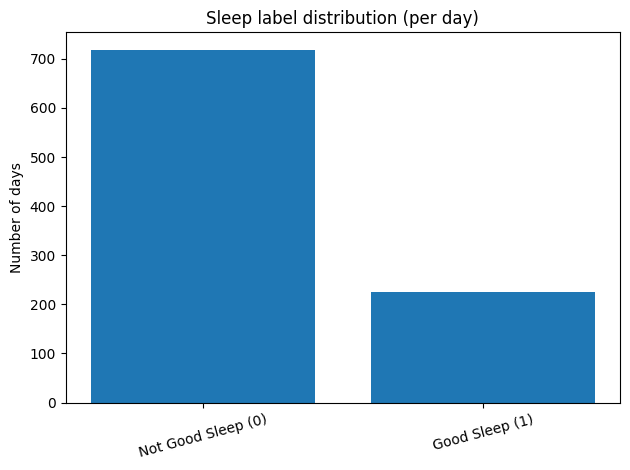

Class balance (%):
GoodSleep
0    76.139979
1    23.860021
Name: count, dtype: float64


In [8]:
counts = plot_df[label_col].value_counts().sort_index()
labels = ['Not Good Sleep (0)', 'Good Sleep (1)']

plt.figure()
plt.bar(labels, counts.values)
plt.title("Sleep label distribution (per day)")
plt.ylabel("Number of days")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Class balance (%):")
print((counts / counts.sum()) * 100)

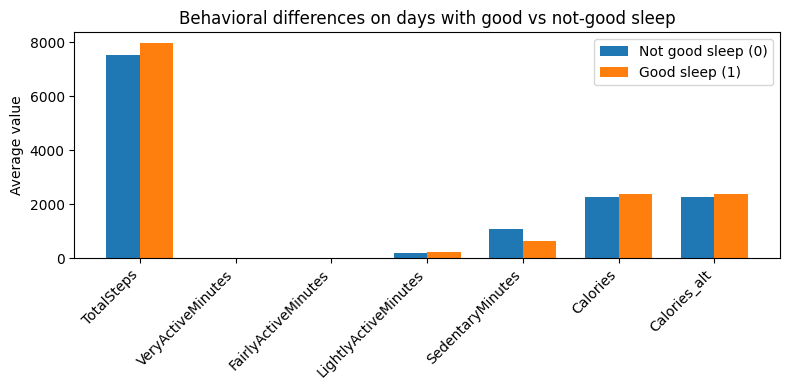

GoodSleep,0,1
TotalSteps,7551.218663,7974.395556
VeryActiveMinutes,21.288301,21.084444
FairlyActiveMinutes,13.498607,14.044444
LightlyActiveMinutes,183.529248,223.328889
SedentaryMinutes,1094.289694,658.680000
Calories,2282.015320,2388.857778
Calories_alt,2282.015320,2388.857778


In [9]:
group_means = plot_df.groupby(label_col)[feature_cols_nohr].mean().T
# now rows are features and columns are 0 / 1 (label)

plt.figure(figsize=(8, 4))
x = np.arange(len(feature_cols_nohr))

width = 0.35
plt.bar(x - width/2, group_means[0], width, label="Not good sleep (0)")
plt.bar(x + width/2, group_means[1], width, label="Good sleep (1)")

plt.xticks(x, feature_cols_nohr, rotation=45, ha='right')
plt.ylabel("Average value")
plt.title("Behavioral differences on days with good vs not-good sleep")
plt.legend()
plt.tight_layout()
plt.show()

group_means


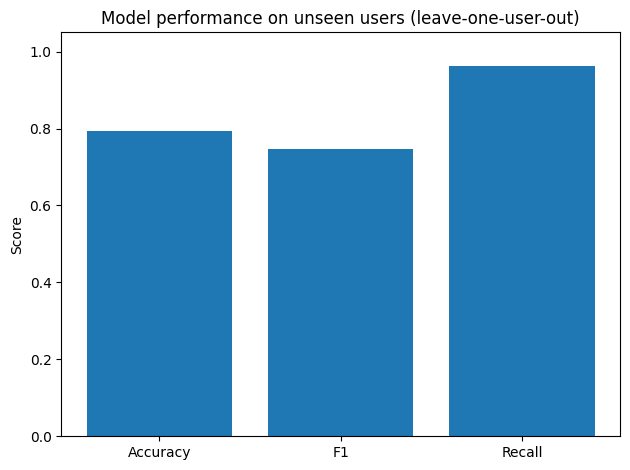

In [10]:
accuracy_nohr = 0.793
f1_nohr = 0.746
recall_nohr = 0.962

metrics = ['Accuracy', 'F1', 'Recall']
values = [accuracy_nohr, f1_nohr, recall_nohr]

plt.figure()
plt.bar(metrics, values)
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Model performance on unseen users (leave-one-user-out)")
plt.tight_layout()
plt.show()

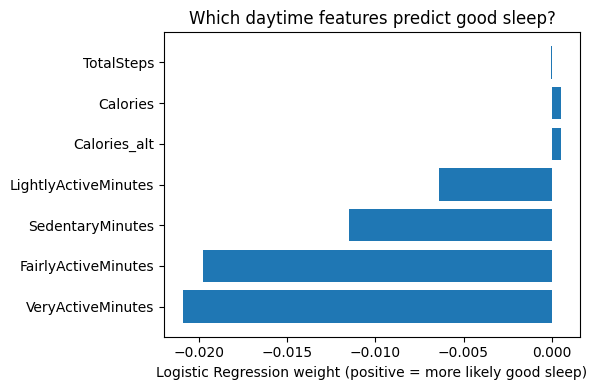

VeryActiveMinutes         -0.021
FairlyActiveMinutes       -0.020
SedentaryMinutes          -0.011
LightlyActiveMinutes      -0.006
Calories_alt              0.001
Calories                  0.001
TotalSteps                -0.000


In [11]:
from sklearn.linear_model import LogisticRegression

# train a model on all data (only to get coefficients for interpretation/plotting)
X_all = plot_df[feature_cols_nohr].fillna(plot_df[feature_cols_nohr].mean()).values
y_all = plot_df[label_col].values

model_global = LogisticRegression(max_iter=1000, class_weight='balanced')
model_global.fit(X_all, y_all)

coefs = model_global.coef_[0]  # logistic regression weights for GoodSleep=1
feat_names = feature_cols_nohr

# plot as a horizontal bar chart, sorted by absolute value to make it clearer
order = np.argsort(np.abs(coefs))[::-1]
coefs_sorted = coefs[order]
feat_sorted = [feat_names[i] for i in order]

plt.figure(figsize=(6, 4))
plt.barh(feat_sorted, coefs_sorted)
plt.xlabel("Logistic Regression weight (positive = more likely good sleep)")
plt.title("Which daytime features predict good sleep?")
plt.tight_layout()
plt.show()

for name, w in zip(feat_sorted, coefs_sorted):
    print(f"{name:25s} {w:.3f}")


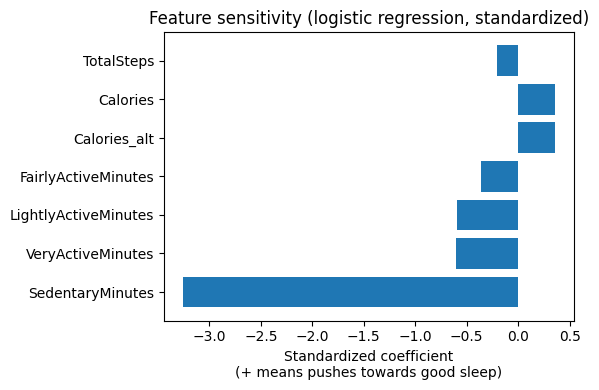

SedentaryMinutes           coef=-3.259
VeryActiveMinutes          coef=-0.602
LightlyActiveMinutes       coef=-0.591
FairlyActiveMinutes        coef=-0.361
Calories_alt               coef=+0.361
Calories                   coef=+0.361
TotalSteps                 coef=-0.209


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# use the feature set without heart rate (cleaner)
feature_cols = [
    'TotalSteps',
    'VeryActiveMinutes',
    'FairlyActiveMinutes',
    'LightlyActiveMinutes',
    'SedentaryMinutes',
    'Calories',
    'Calories_alt'
]

label_col = 'GoodSleep'

# prepare data
sens_df = full_df[feature_cols + [label_col]].dropna(subset=[label_col]).copy()

# simple imputation: fill rare NaNs with the column mean
for col in feature_cols:
    sens_df[col] = sens_df[col].fillna(sens_df[col].mean())

X = sens_df[feature_cols].values
y = sens_df[label_col].values

# standardize so each feature has mean 0 and variance 1
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# train a global model (not LOO; just to inspect sensitivity)
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_std, y)

coefs = clf.coef_[0]  # coefficient for each feature
abs_coefs = np.abs(coefs)

# sort by absolute value and plot
order = np.argsort(abs_coefs)[::-1]
feat_sorted = [feature_cols[i] for i in order]
coef_sorted = coefs[order]

plt.figure(figsize=(6, 4))
plt.barh(feat_sorted, coef_sorted)
plt.xlabel("Standardized coefficient\n(+ means pushes towards good sleep)")
plt.title("Feature sensitivity (logistic regression, standardized)")
plt.tight_layout()
plt.show()

# print values for easier interpretation
for name, w in zip(feat_sorted, coef_sorted):
    print(f"{name:25s}  coef={w:+.3f}")


In [13]:
print("Raw SedentaryMinutes from full_df (before any scaling):")
print(full_df['SedentaryMinutes'].describe())

print("\nA few sample values:")
print(full_df['SedentaryMinutes'].head(20).tolist())

Raw SedentaryMinutes from full_df (before any scaling):
count     943.000000
mean      990.353128
std       301.262473
min         0.000000
25%       729.000000
50%      1057.000000
75%      1229.000000
max      1440.000000
Name: SedentaryMinutes, dtype: float64

A few sample values:
[728, 776, 1218, 726, 773, 539, 1149, 775, 818, 838, 1217, 732, 709, 814, 833, 1108, 782, 815, 712, 730]
